<a href="https://colab.research.google.com/github/Arpon7/VoltVARControl/blob/main/VoltVARControl_V2.0/Base_paper_Repo_Stable_DDPG_for_voltage_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/JieFeng-cse/Stable-DDPG-for-voltage-control.git
%cd Stable-DDPG-for-voltage-control

Cloning into 'Stable-DDPG-for-voltage-control'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (256/256), done.
remote: Total 333 (delta 90), reused 309 (delta 71), pack-reused 0 (from 0)
Receiving objects: 100% (333/333), 4.79 MiB | 20.85 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/Stable-DDPG-for-voltage-control


In [ ]:
!pip install -q pandapower numba

In [ ]:
import sys
import numpy
import scipy
import pandas
import pandapower
import gym

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pandas.__version__)
print("Gym:", gym.__version__)
print("pandapower:", pandapower.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
SciPy: 1.18.0
Pandas: 2.3.3
Gym: 0.25.2
pandapower: 3.5.4


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
!sed -i "s/pp_net = pp.converter.from_mpc(/pp_net = from_mpc(/" env_single_phase_13bus.py
!sed -i "/import pandapower.networks as pn/a from pandapower.converter.matpower import from_mpc" env_single_phase_13bus.py
!sed -i "s/pp_net = pp.converter.from_mpc(/pp_net = from_mpc(/" env_single_phase_123bus.py
!sed -i "/import pandapower.networks as pn/a from pandapower.converter.matpower import from_mpc" env_single_phase_123bus.py

In [ ]:
!find "pandapower models" -type f

pandapower models/__MACOSX/pandapower models/._123bus.png
pandapower models/__MACOSX/pandapower models/._case_13.mat
pandapower models/__MACOSX/pandapower models/._case123.m
pandapower models/__MACOSX/pandapower models/._.DS_Store
pandapower models/__MACOSX/pandapower models/._13bus.png
pandapower models/__MACOSX/pandapower models/._13bus.docx
pandapower models/__MACOSX/pandapower models/._case_123.mat
pandapower models/pandapower models/13bus.docx
pandapower models/pandapower models/case_123.mat
pandapower models/pandapower models/123bus.png
pandapower models/pandapower models/.ipynb_checkpoints/IEEE_13bus_pandapower-checkpoint.ipynb
pandapower models/pandapower models/.ipynb_checkpoints/IEEE_123bus_pandapower-checkpoint.ipynb
pandapower models/pandapower models/13bus.png
pandapower models/pandapower models/.DS_Store
pandapower models/pandapower models/case_13.mat


In [ ]:
!python env_single_phase_13bus.py

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotl

In [ ]:
!python env_single_phase_123bus.py

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotl

/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode * 0 * Avg Reward is ==> -84.81601920811195


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Episode * 50 * Avg Reward is ==> -7.350535237448307


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Episode * 100 * Avg Reward is ==> -4.520117564160509


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Episode * 150 * Avg Reward is ==> -4.264028710577444


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

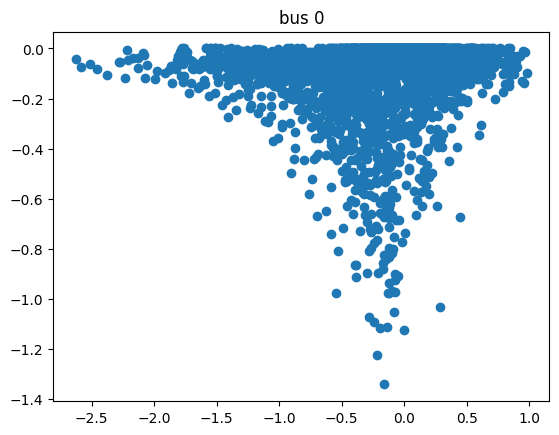

/tmp/ipykernel_1174/3592255891.py:335: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s_array[j] = state


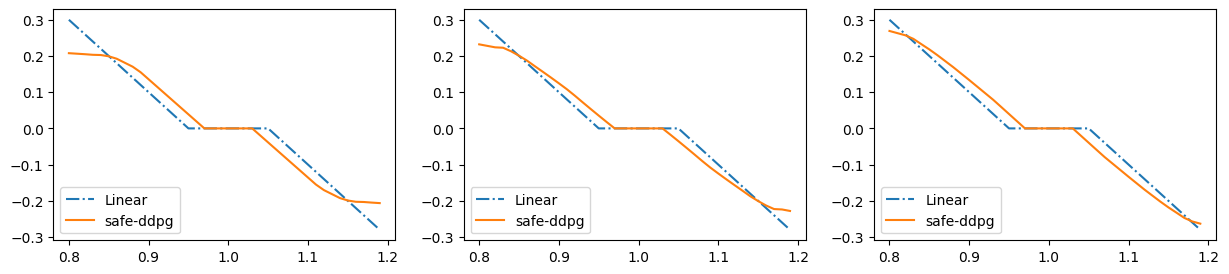

finished
finished
finished
finished
finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished
finished
finished
finished


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


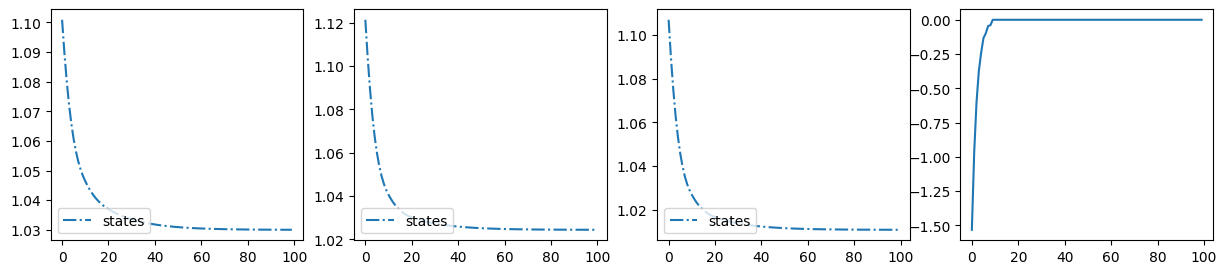

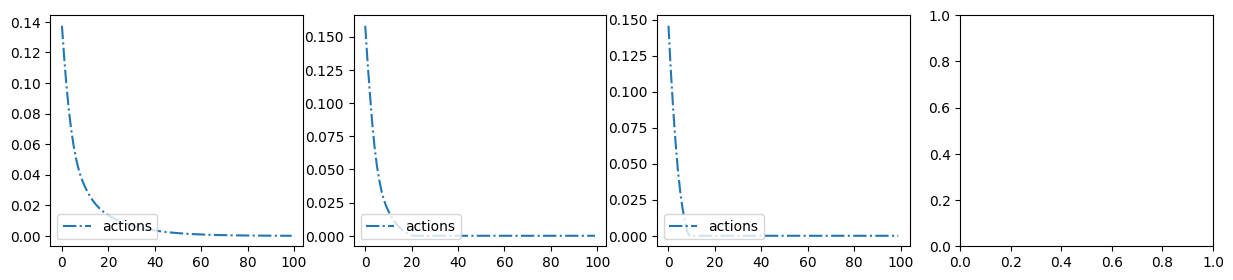

In [ ]:
### Modified train-DDPG.py: no need to pass argument. Default values are set. args = parser.parse_args([]) # Modified this line
### import collections
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as LA
import gym
import os
import random
import sys
from gym import spaces
from gym.utils import seeding
import copy

from scipy.io import loadmat
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import argparse

from env_single_phase_13bus import IEEE13bus, create_13bus
from env_single_phase_123bus import IEEE123bus, create_123bus
# from IEEE_13_3p import IEEE13bus3p, create_13bus3p
# from IEEE_123_3p import IEEE123bus3p, create_123bus3p
from safeDDPG import ValueNetwork, SafePolicyNetwork, DDPG, ReplayBuffer, ReplayBufferPI, PolicyNetwork, SafePolicy3phase, LinearPolicy

use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")

parser = argparse.ArgumentParser(description='Single Phase Safe DDPG')
parser.add_argument('--env_name', default="13bus",
                    help='name of the environment to run')
parser.add_argument('--algorithm', default='safe-ddpg', help='name of algorithm')
parser.add_argument('--status', default='train')
parser.add_argument('--safe_type', default='three_single') #loss, dd
args = parser.parse_args([]) # Modified this line
seed = 10
torch.manual_seed(seed)


"""
Create Agent list and replay buffer
"""
vlr = 2e-4
plr = 1e-4
ph_num = 1
max_ac = 0.3
if args.env_name == '13bus':
    pp_net = create_13bus()
    injection_bus = np.array([2, 7, 9])
    # injection_bus = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
    env = IEEE13bus(pp_net, injection_bus)
    num_agent = len(injection_bus)
if args.env_name == '123bus':
    max_ac = 0.8
    pp_net = create_123bus()
    injection_bus = np.array([10, 11, 16, 20, 33, 36, 48, 59, 66, 75, 83, 92, 104, 61])-1
    env = IEEE123bus(pp_net, injection_bus)
    num_agent = 14
    if args.algorithm == 'safe-ddpg':
        plr = 1.5e-4

if args.env_name == '13bus3p':
    # injection_bus = np.array([675,633,680])
    injection_bus = np.array([633,634,671,645,646,692,675,611,652,632,680,684])
    pp_net, injection_bus_dict = create_13bus3p(injection_bus)
    max_ac = 0.5
    env = IEEE13bus3p(pp_net,injection_bus_dict)
    num_agent = len(injection_bus)
    ph_num=3
    if args.algorithm == 'safe-ddpg':
        plr = 1e-4
    if args.algorithm == 'ddpg':
        plr = 5e-5

if args.env_name == '123bus3p':
    injection_bus = np.array([10, 11, 16, 20, 33, 36, 48, 59, 66, 75, 83, 92, 104, 61])
    net, injection_bus_dict = create_123bus3p(injection_bus)
    env = IEEE123bus3p(net, injection_bus_dict)
    num_agent = len(injection_bus)
    max_ac = 0.5
    ph_num=3
    if args.algorithm == 'safe-ddpg':
        plr = 5e-5
    if args.algorithm == 'linear':
        plr =5e-5
    if args.algorithm == 'ddpg':
        plr = 1e-5



obs_dim = env.obs_dim
action_dim = env.action_dim
hidden_dim = 100
if ph_num == 3:
    type_name = 'three-phase'
else:
    type_name = 'single-phase'

agent_list = []
replay_buffer_list = []

for i in range(num_agent):
    if ph_num == 3:
        obs_dim = len(env.injection_bus[env.injection_bus_str[i]])
        action_dim = obs_dim
    value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    if args.algorithm == 'safe-ddpg' and not ph_num == 3:
        policy_net = SafePolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
        target_policy_net = SafePolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    elif args.algorithm == 'safe-ddpg' and ph_num == 3 and args.safe_type == 'three_single':
        policy_net = SafePolicy3phase(env, obs_dim, action_dim, hidden_dim, env.injection_bus_str[i]).to(device)
        target_policy_net = SafePolicy3phase(env, obs_dim, action_dim, hidden_dim, env.injection_bus_str[i]).to(device)
    elif args.algorithm == 'linear':
        policy_net = LinearPolicy(env,ph_num)
        target_policy_net = LinearPolicy(env,ph_num)
    else:
        policy_net = PolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
        target_policy_net = PolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)

    target_value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)


    for target_param, param in zip(target_value_net.parameters(), value_net.parameters()):
        target_param.data.copy_(param.data)

    for target_param, param in zip(target_policy_net.parameters(), policy_net.parameters()):
        target_param.data.copy_(param.data)

    agent = DDPG(policy_net=policy_net, value_net=value_net,
                 target_policy_net=target_policy_net, target_value_net=target_value_net, value_lr=vlr, policy_lr=plr)

    replay_buffer = ReplayBufferPI(capacity=1000000)

    agent_list.append(agent)
    replay_buffer_list.append(replay_buffer)

if args.status =='train':
    FLAG = 1
else:
    FLAG = 0
def get_id(phases):
    if phases == 'abc':
        id = [0,1,2]
    elif phases == 'ab':
        id = [0,1]
    elif phases == 'ac':
        id = [0,2]
    elif phases == 'bc':
        id = [1,2]
    elif phases == 'a':
        id = [0]
    elif phases == 'b':
        id = [1]
    elif phases == 'c':
        id = [2]
    else:
        print("error!")
        exit(0)
    return id

if (FLAG ==0):
    # load trained policy
    for i in range(num_agent):
        if ph_num == 3 and args.algorithm=='safe-ddpg':
            policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type}/policy_net_checkpoint_a{i}.pth')
        else:
            policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/policy_net_checkpoint_a{i}.pth')
        agent_list[i].policy_net.load_state_dict(policynet_dict)

elif (FLAG ==1):
    # training episode
    # for i in range(num_agent): #this part is to load the linear model initialization for three-phase test scenario
    #     if ph_num == 3 and args.algorithm=='safe-ddpg':
    #         valuenet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type} copy/value_net_checkpoint_a{i}.pth')
    #         policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type} copy/policy_net_checkpoint_a{i}.pth')
    #     else:
    #         valuenet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm} copy/value_net_checkpoint_a{i}.pth')
    #         policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm} copy/policy_net_checkpoint_a{i}.pth')
    #     agent_list[i].value_net.load_state_dict(valuenet_dict)
    #     agent_list[i].policy_net.load_state_dict(policynet_dict)
    #     for target_param, param in zip(agent_list[i].target_value_net.parameters(), agent_list[i].value_net.parameters()):
    #         target_param.data.copy_(param.data)

    #     for target_param, param in zip(agent_list[i].target_policy_net.parameters(), agent_list[i].policy_net.parameters()):
    #         target_param.data.copy_(param.data)

    if args.algorithm == 'safe-ddpg':
        num_episodes = 200    #13-3p
        # num_episodes = 700
    else:
        # num_episodes = 700 #123 2000 13-3p 700
        num_episodes = 700

    # trajetory length each episode
    num_steps = 30
    if args.env_name =='123bus':
        num_steps = 60
    if args.env_name =='eu-lv':
        num_steps = 30
        # num_episodes *= 2
    if args.env_name =='13bus3p':
        num_steps = 30
    if args.env_name =='123bus3p':
        num_steps = 100
    batch_size = 256

    rewards = []
    avg_reward_list = []
    for episode in range(num_episodes):

        state = env.reset(seed = episode)
        episode_reward = 0
        last_action = np.zeros((num_agent,ph_num)) #if single phase, 1, else ,3

        for step in range(num_steps):
            action = []
            action_p = []
            for i in range(num_agent):
                # sample action according to the current policy and exploration noise
                if ph_num==3:
                    action_agent = np.zeros(3)
                    phases = env.injection_bus[env.injection_bus_str[i]]
                    id = get_id(phases)
                    action_tmp = agent_list[i].policy_net.get_action(np.asarray([state[i,id]])) + np.random.normal(0, max_ac)/np.sqrt(episode+1)
                    action_tmp = action_tmp.reshape(len(id),)
                    for j in range(len(phases)):
                        action_agent[id[j]]=action_tmp[j]
                    # action_p.append(action_agent)
                    action_agent = np.clip(action_agent, -max_ac, max_ac)
                    action_p.append(action_agent)
                else:
                    action_agent = agent_list[i].policy_net.get_action(np.asarray([state[i]]))  + np.random.normal(0, max_ac)/np.sqrt(episode+1)
                    action_agent = np.clip(action_agent, -max_ac, max_ac)
                    action_p.append(action_agent)
                action.append(action_agent)

            # PI policy
            if ph_num == 3:
                action = last_action - np.asarray(action).reshape(-1,3) #.reshape(-1,3) #if eu, reshape
            else:
                action = last_action - np.asarray(action)

            # execute action a_t and observe reward r_t and observe next state s_{t+1}
            next_state, reward, reward_sep, done = env.step_Preward(action, action_p)

            if(np.min(next_state)<0.75): #if voltage violation > 25%, episode ends.
                break
            else:
                for i in range(num_agent):
                    if ph_num == 1:
                        state_buffer = state[i].reshape(ph_num,)
                        action_buffer = action[i].reshape(ph_num,)
                        last_action_buffer = last_action[i].reshape(ph_num,)
                        next_state_buffer = next_state[i].reshape(ph_num, )
                    else:
                        phases = env.injection_bus[env.injection_bus_str[i]]
                        id = get_id(phases)
                        state_buffer = state[i,id].reshape(len(phases),)
                        action_buffer = action[i,id].reshape(len(phases),)
                        last_action_buffer = last_action[i,id].reshape(len(phases),)
                        next_state_buffer = next_state[i,id].reshape(len(phases),)
                    # store transition (s_t, a_t, r_t, s_{t+1}) in R
                    replay_buffer_list[i].push(state_buffer, action_buffer, last_action_buffer,
                                               reward_sep[i], next_state_buffer, done) #_sep[i]

                    # update both critic and actor network
                    if ph_num == 3 and args.algorithm == 'safe-ddpg' and args.safe_type == 'loss':
                        if len(replay_buffer_list[i]) > batch_size:
                            agent_list[i].train_step_3ph(replay_buffer=replay_buffer_list[i],
                                                    batch_size=batch_size)
                    else:
                        if len(replay_buffer_list[i]) > batch_size:
                            agent_list[i].train_step(replay_buffer=replay_buffer_list[i],
                                                    batch_size=batch_size)

                if(done):
                    episode_reward += reward
                    break #no break if 13bus3p
                else:
                    state = np.copy(next_state)
                    episode_reward += reward

            last_action = np.copy(action)

        rewards.append(episode_reward)
        avg_reward = np.mean(rewards[-40:])
        if(episode%50==0):
            print("Episode * {} * Avg Reward is ==> {}".format(episode, avg_reward))
        avg_reward_list.append(avg_reward)
    # for i in range(num_agent): #save model, you can customize the path
    #     if ph_num == 3 and args.algorithm=='safe-ddpg':
    #         pth_value = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type}/value_net_checkpoint_a{i}.pth'
    #         pth_policy = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type}/policy_net_checkpoint_a{i}.pth'
    #     else:
    #         pth_value = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/value_net_checkpoint_a{i}.pth'
    #         pth_policy = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/policy_net_checkpoint_a{i}.pth'
    #     torch.save(agent_list[i].value_net.state_dict(), pth_value)
    #     torch.save(agent_list[i].policy_net.state_dict(), pth_policy)

else:
    raise ValueError("Model loading optition does not exist!")
# torch.save(torch.tensor(rewards),'rewards_ddpg_q1.pt')
# print(torch.tensor(rewards).shape)

if args.status == 'train':
    check_buffer = replay_buffer_list[0]
    buffer_len = replay_buffer_list[0].__len__()
    state, action, last_action, reward, next_state, done = replay_buffer_list[0].sample(buffer_len-1)
    if ph_num==1:
        plt.scatter(action,reward)
        plt.title('bus 0')
        plt.savefig('bus0.png')
        plt.show()
    else:
        plt.scatter(action[:,0],reward)
        plt.title('bus 0')
        plt.savefig('bus0.png')
        plt.show()


fig, axs = plt.subplots(1, num_agent, figsize=(15,3))
for i in range(num_agent):
    N = 40
    s_array = np.zeros(N,)

    a_array_baseline = np.zeros(N,)
    a_array = np.zeros((N,ph_num))

    for j in range(N):
        if ph_num ==1:
            state = np.array([0.8+0.01*j])
            s_array[j] = state
            action_baseline = (np.maximum(state-1.05, 0)-np.maximum(0.95-state, 0)).reshape((1,))
        else:
            state = np.resize(np.array([0.8+0.01*j]),(3))
            s_array[j] = state[0]
            action_baseline = (np.maximum(state[0]-1.03, 0)-np.maximum(0.97-state[0], 0)).reshape((1,))
        if ph_num == 3:
            action = np.zeros(3)
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            action_tmp = agent_list[i].policy_net.get_action(np.asarray([state[id]]))
            action_tmp = action_tmp.reshape(len(id),)
            for p in range(len(phases)):
                action[id[p]]=action_tmp[p]
        else:
            action = agent_list[i].policy_net.get_action(np.asarray([state]))
        action = np.clip(action, -max_ac, max_ac)
        a_array_baseline[j] = -action_baseline[0]
        a_array[j] = -action
    axs[i].plot(s_array, 2*a_array_baseline, '-.', label = 'Linear')
    for k in range(ph_num):
        axs[i].plot(s_array, a_array[:,k], label = args.algorithm)
        axs[i].legend(loc='lower left')
plt.show()

## test policy
state = env.reset()
episode_reward = 0
last_action = np.zeros((num_agent,1))
action_list=[]
state_list =[]
reward_list = []
state_list.append(state)
for step in range(100):
    action = []
    for i in range(num_agent):
        # sample action according to the current policy and exploration noise
        if ph_num==3:
            action_agent = np.zeros(3)
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            action_tmp = agent_list[i].policy_net.get_action(np.asarray([state[i,id]]))
            action_tmp = action_tmp.reshape(len(id),)
            for i in range(len(phases)):
                action_agent[id[i]]=action_tmp[i]
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)
        else:
            action_agent = agent_list[i].policy_net.get_action(np.asarray([state[i]]))
            # action_agent = (np.maximum(state[i]-1.05, 0)-np.maximum(0.95-state[i], 0)).reshape((1,))
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)

    # PI policy
    action = last_action - np.asarray(action)

    # execute action a_t and observe reward r_t and observe next state s_{t+1}
    next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
    reward_list.append(reward)
    if done:
        print("finished")
    action_list.append(last_action-action)
    state_list.append(next_state)
    last_action = np.copy(action)
    state = next_state
fig, axs = plt.subplots(1, num_agent+1, figsize=(15,3))
for i in range(num_agent):
    axs[i].plot(range(len(action_list)), np.array(state_list)[:len(action_list),i], '-.', label = 'states')
    # axs[i].plot(range(len(action_list)), np.array(action_list)[:,i], label = 'action')
    axs[i].legend(loc='lower left')
fig1, axs1 = plt.subplots(1, num_agent+1, figsize=(15,3))
for i in range(num_agent):
    axs1[i].plot(range(len(action_list)), np.array(action_list)[:len(action_list),i], '-.', label = 'actions')
    # axs[i].plot(range(len(action_list)), np.array(action_list)[:,i], label = 'action')
    axs1[i].legend(loc='lower left')
axs[num_agent].plot(range(len(reward_list)),reward_list)
plt.show()

# test success rate:


/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/tmp/ipykernel_1174/1626341576.py:336: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s_array[j] = state
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


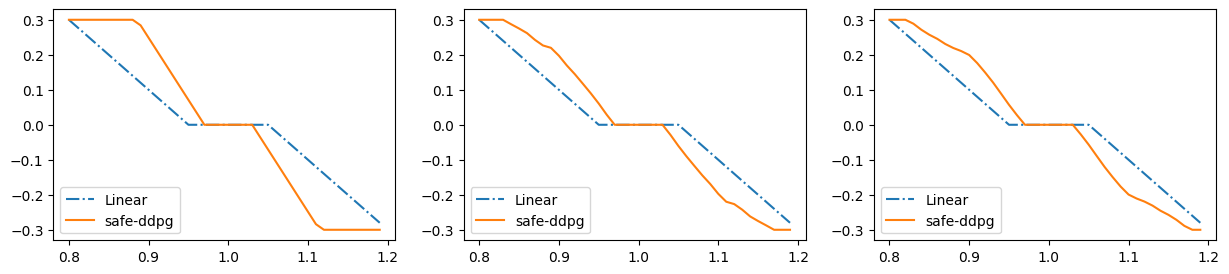

finished
finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


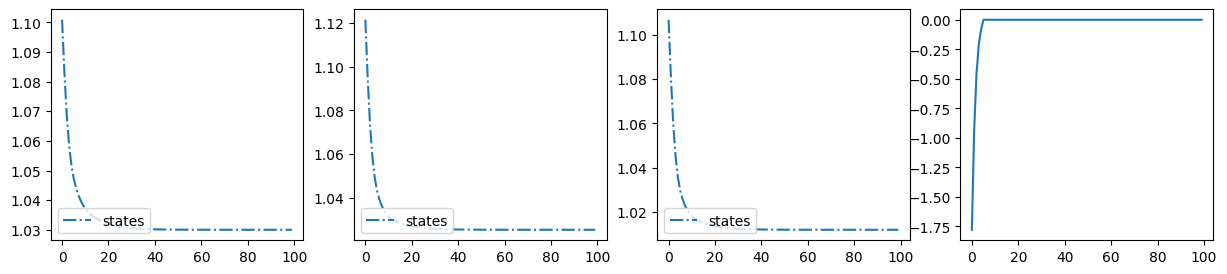

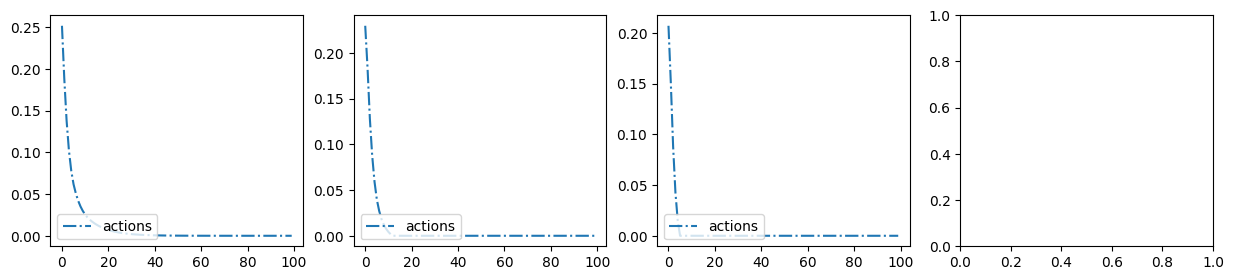

In [ ]:
#Default: TEST ### Modified train-DDPG.py: no need to pass argument. This ensures 10 test runs. Default values are set. args = parser.parse_args([]) # Modified this line
### import collections
import matplotlib.pyplot as plt
import numpy as np
from numpy import linalg as LA
import gym
import os
import random
import sys
from gym import spaces
from gym.utils import seeding
import copy

from scipy.io import loadmat
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import argparse

from env_single_phase_13bus import IEEE13bus, create_13bus
from env_single_phase_123bus import IEEE123bus, create_123bus
# from IEEE_13_3p import IEEE13bus3p, create_13bus3p
# from IEEE_123_3p import IEEE123bus3p, create_123bus3p
from safeDDPG import ValueNetwork, SafePolicyNetwork, DDPG, ReplayBuffer, ReplayBufferPI, PolicyNetwork, SafePolicy3phase, LinearPolicy

use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")

parser = argparse.ArgumentParser(description='Single Phase Safe DDPG')
parser.add_argument('--env_name', default="13bus",
                    help='name of the environment to run')
parser.add_argument('--algorithm', default='safe-ddpg', help='name of algorithm')
parser.add_argument('--status', default='test')
parser.add_argument('--safe_type', default='three_single') #loss, dd
args = parser.parse_args([]) # Modified this line
seed = 10
torch.manual_seed(seed)


"""
Create Agent list and replay buffer
"""
vlr = 2e-4
plr = 1e-4
ph_num = 1
max_ac = 0.3
if args.env_name == '13bus':
    pp_net = create_13bus()
    injection_bus = np.array([2, 7, 9])
    # injection_bus = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
    env = IEEE13bus(pp_net, injection_bus)
    num_agent = len(injection_bus)
if args.env_name == '123bus':
    max_ac = 0.8
    pp_net = create_123bus()
    injection_bus = np.array([10, 11, 16, 20, 33, 36, 48, 59, 66, 75, 83, 92, 104, 61])-1
    env = IEEE123bus(pp_net, injection_bus)
    num_agent = 14
    if args.algorithm == 'safe-ddpg':
        plr = 1.5e-4

if args.env_name == '13bus3p':
    # injection_bus = np.array([675,633,680])
    injection_bus = np.array([633,634,671,645,646,692,675,611,652,632,680,684])
    pp_net, injection_bus_dict = create_13bus3p(injection_bus)
    max_ac = 0.5
    env = IEEE13bus3p(pp_net,injection_bus_dict)
    num_agent = len(injection_bus)
    ph_num=3
    if args.algorithm == 'safe-ddpg':
        plr = 1e-4
    if args.algorithm == 'ddpg':
        plr = 5e-5

if args.env_name == '123bus3p':
    injection_bus = np.array([10, 11, 16, 20, 33, 36, 48, 59, 66, 75, 83, 92, 104, 61])
    net, injection_bus_dict = create_123bus3p(injection_bus)
    env = IEEE123bus3p(net, injection_bus_dict)
    num_agent = len(injection_bus)
    max_ac = 0.5
    ph_num=3
    if args.algorithm == 'safe-ddpg':
        plr = 5e-5
    if args.algorithm == 'linear':
        plr =5e-5
    if args.algorithm == 'ddpg':
        plr = 1e-5



obs_dim = env.obs_dim
action_dim = env.action_dim
hidden_dim = 100
if ph_num == 3:
    type_name = 'three-phase'
else:
    type_name = 'single-phase'

agent_list = []
replay_buffer_list = []

for i in range(num_agent):
    if ph_num == 3:
        obs_dim = len(env.injection_bus[env.injection_bus_str[i]])
        action_dim = obs_dim
    value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    if args.algorithm == 'safe-ddpg' and not ph_num == 3:
        policy_net = SafePolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
        target_policy_net = SafePolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    elif args.algorithm == 'safe-ddpg' and ph_num == 3 and args.safe_type == 'three_single':
        policy_net = SafePolicy3phase(env, obs_dim, action_dim, hidden_dim, env.injection_bus_str[i]).to(device)
        target_policy_net = SafePolicy3phase(env, obs_dim, action_dim, hidden_dim, env.injection_bus_str[i]).to(device)
    elif args.algorithm == 'linear':
        policy_net = LinearPolicy(env,ph_num)
        target_policy_net = LinearPolicy(env,ph_num)
    else:
        policy_net = PolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
        target_policy_net = PolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)

    target_value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)


    for target_param, param in zip(target_value_net.parameters(), value_net.parameters()):
        target_param.data.copy_(param.data)

    for target_param, param in zip(target_policy_net.parameters(), policy_net.parameters()):
        target_param.data.copy_(param.data)

    agent = DDPG(policy_net=policy_net, value_net=value_net,
                 target_policy_net=target_policy_net, target_value_net=target_value_net, value_lr=vlr, policy_lr=plr)

    replay_buffer = ReplayBufferPI(capacity=1000000)

    agent_list.append(agent)
    replay_buffer_list.append(replay_buffer)

if args.status =='train':
    FLAG = 1
else:
    FLAG = 0
def get_id(phases):
    if phases == 'abc':
        id = [0,1,2]
    elif phases == 'ab':
        id = [0,1]
    elif phases == 'ac':
        id = [0,2]
    elif phases == 'bc':
        id = [1,2]
    elif phases == 'a':
        id = [0]
    elif phases == 'b':
        id = [1]
    elif phases == 'c':
        id = [2]
    else:
        print("error!")
        exit(0)
    return id

if (FLAG ==0):
    # load trained policy
    for i in range(num_agent):
        if ph_num == 3 and args.algorithm=='safe-ddpg':
            policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type}/policy_net_checkpoint_a{i}.pth', map_location=device)
        else:
            policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/policy_net_checkpoint_a{i}.pth', map_location=device)
        agent_list[i].policy_net.load_state_dict(policynet_dict)

elif (FLAG ==1):
    # training episode
    # for i in range(num_agent): #this part is to load the linear model initialization for three-phase test scenario
    #     if ph_num == 3 and args.algorithm=='safe-ddpg':
    #         valuenet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type} copy/value_net_checkpoint_a{i}.pth')
    #         policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type} copy/policy_net_checkpoint_a{i}.pth')
    #     else:
    #         valuenet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm} copy/value_net_checkpoint_a{i}.pth')
    #         policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/{args.algorithm} copy/policy_net_checkpoint_a{i}.pth')
    #     agent_list[i].value_net.load_state_dict(valuenet_dict)
    #     agent_list[i].policy_net.load_state_dict(policynet_dict)
    #     for target_param, param in zip(agent_list[i].target_value_net.parameters(), agent_list[i].value_net.parameters()):
    #         target_param.data.copy_(param.data)

    #     for target_param, param in zip(agent_list[i].target_policy_net.parameters(), agent_list[i].policy_net.parameters()):
    #         target_param.data.copy_(param.data)

    if args.algorithm == 'safe-ddpg':
        num_episodes = 200    #13-3p
        # num_episodes = 700
    else:
        # num_episodes = 700 #123 2000 13-3p 700
        num_episodes = 700

    # trajetory length each episode
    num_steps = 30
    if args.env_name =='123bus':
        num_steps = 60
    if args.env_name =='eu-lv':
        num_steps = 30
        # num_episodes *= 2
    if args.env_name =='13bus3p':
        num_steps = 30
    if args.env_name =='123bus3p':
        num_steps = 100
    batch_size = 256

    rewards = []
    avg_reward_list = []
    for episode in range(num_episodes):

        state = env.reset(seed = episode)
        episode_reward = 0
        last_action = np.zeros((num_agent,ph_num)) #if single phase, 1, else ,3

        for step in range(num_steps):
            action = []
            action_p = []
            for i in range(num_agent):
                # sample action according to the current policy and exploration noise
                if ph_num==3:
                    action_agent = np.zeros(3)
                    phases = env.injection_bus[env.injection_bus_str[i]]
                    id = get_id(phases)
                    action_tmp = agent_list[i].policy_net.get_action(np.asarray([state[i,id]])) + np.random.normal(0, max_ac)/np.sqrt(episode+1)
                    action_tmp = action_tmp.reshape(len(id),)
                    for j in range(len(phases)):
                        action_agent[id[j]]=action_tmp[j]
                    # action_p.append(action_agent)
                    action_agent = np.clip(action_agent, -max_ac, max_ac)
                    action_p.append(action_agent)
                else:
                    action_agent = agent_list[i].policy_net.get_action(np.asarray([state[i]]))  + np.random.normal(0, max_ac)/np.sqrt(episode+1)
                    action_agent = np.clip(action_agent, -max_ac, max_ac)
                    action_p.append(action_agent)
                action.append(action_agent)

            # PI policy
            if ph_num == 3:
                action = last_action - np.asarray(action).reshape(-1,3) #.reshape(-1,3) #if eu, reshape
            else:
                action = last_action - np.asarray(action)

            # execute action a_t and observe reward r_t and observe next state s_{t+1}
            next_state, reward, reward_sep, done = env.step_Preward(action, action_p)

            if(np.min(next_state)<0.75): #if voltage violation > 25%, episode ends.
                break
            else:
                for i in range(num_agent):
                    if ph_num == 1:
                        state_buffer = state[i].reshape(ph_num,)
                        action_buffer = action[i].reshape(ph_num,)
                        last_action_buffer = last_action[i].reshape(ph_num,)
                        next_state_buffer = next_state[i].reshape(ph_num, )
                    else:
                        phases = env.injection_bus[env.injection_bus_str[i]]
                        id = get_id(phases)
                        state_buffer = state[i,id].reshape(len(phases),)
                        action_buffer = action[i,id].reshape(len(phases),)
                        last_action_buffer = last_action[i,id].reshape(len(phases),)
                        next_state_buffer = next_state[i,id].reshape(len(phases),)
                    # store transition (s_t, a_t, r_t, s_{t+1}) in R
                    replay_buffer_list[i].push(state_buffer, action_buffer, last_action_buffer,
                                               reward_sep[i], next_state_buffer, done) #_sep[i]

                    # update both critic and actor network
                    if ph_num == 3 and args.algorithm == 'safe-ddpg' and args.safe_type == 'loss':
                        if len(replay_buffer_list[i]) > batch_size:
                            agent_list[i].train_step_3ph(replay_buffer=replay_buffer_list[i],
                                                    batch_size=batch_size)
                    else:
                        if len(replay_buffer_list[i]) > batch_size:
                            agent_list[i].train_step(replay_buffer=replay_buffer_list[i],
                                                    batch_size=batch_size)

                if(done):
                    episode_reward += reward
                    break #no break if 13bus3p
                else:
                    state = np.copy(next_state)
                    episode_reward += reward

            last_action = np.copy(action)

        rewards.append(episode_reward)
        avg_reward = np.mean(rewards[-40:])
        if(episode%50==0):
            print("Episode * {} * Avg Reward is ==> {}".format(episode, avg_reward))
        avg_reward_list.append(avg_reward)
    # for i in range(num_agent): #save model, you can customize the path
    #     if ph_num == 3 and args.algorithm=='safe-ddpg':
    #         pth_value = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type}/value_net_checkpoint_a{i}.pth'
    #         pth_policy = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/{args.safe_type}/policy_net_checkpoint_a{i}.pth'
    #     else:
    #         pth_value = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/value_net_checkpoint_a{i}.pth'
    #         pth_policy = f'checkpoints/{type_name}/{args.env_name}/{args.algorithm}/policy_net_checkpoint_a{i}.pth'
    #     torch.save(agent_list[i].value_net.state_dict(), pth_value)
    #     torch.save(agent_list[i].policy_net.state_dict(), pth_policy)

else:
    raise ValueError("Model loading optition does not exist!")
# torch.save(torch.tensor(rewards),'rewards_ddpg_q1.pt')
# print(torch.tensor(rewards).shape)

if args.status == 'train':
    check_buffer = replay_buffer_list[0]
    buffer_len = replay_buffer_list[0].__len__()
    state, action, last_action, reward, next_state, done = replay_buffer_list[0].sample(buffer_len-1)
    if ph_num==1:
        plt.scatter(action,reward)
        plt.title('bus 0')
        plt.savefig('bus0.png')
        plt.show()
    else:
        plt.scatter(action[:,0],reward)
        plt.title('bus 0')
        plt.savefig('bus0.png')
        plt.show()


fig, axs = plt.subplots(1, num_agent, figsize=(15,3))
for i in range(num_agent):
    N = 40
    s_array = np.zeros(N,)

    a_array_baseline = np.zeros(N,)
    a_array = np.zeros((N,ph_num))

    for j in range(N):
        if ph_num ==1:
            state = np.array([0.8+0.01*j])
            s_array[j] = state
            action_baseline = (np.maximum(state-1.05, 0)-np.maximum(0.95-state, 0)).reshape((1,))
        else:
            state = np.resize(np.array([0.8+0.01*j]),(3))
            s_array[j] = state[0]
            action_baseline = (np.maximum(state[0]-1.03, 0)-np.maximum(0.97-state[0], 0)).reshape((1,))
        if ph_num == 3:
            action = np.zeros(3)
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            action_tmp = agent_list[i].policy_net.get_action(np.asarray([state[id]]))
            action_tmp = action_tmp.reshape(len(id),)
            for p in range(len(phases)):
                action[id[p]]=action_tmp[p]
        else:
            action = agent_list[i].policy_net.get_action(np.asarray([state]))
        action = np.clip(action, -max_ac, max_ac)
        a_array_baseline[j] = -action_baseline[0]
        a_array[j] = -action
    axs[i].plot(s_array, 2*a_array_baseline, '-.', label = 'Linear')
    for k in range(ph_num):
        axs[i].plot(s_array, a_array[:,k], label = args.algorithm)
        axs[i].legend(loc='lower left')
plt.show()

## test policy
state = env.reset()
episode_reward = 0
last_action = np.zeros((num_agent,1))
action_list=[]
state_list =[]
reward_list = []
state_list.append(state)
for step in range(100):
    action = []
    for i in range(num_agent):
        # sample action according to the current policy and exploration noise
        if ph_num==3:
            action_agent = np.zeros(3)
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            action_tmp = agent_list[i].policy_net.get_action(np.asarray([state[i,id]]))
            action_tmp = action_tmp.reshape(len(id),)
            for i in range(len(phases)):
                action_agent[id[i]]=action_tmp[i]
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)
        else:
            action_agent = agent_list[i].policy_net.get_action(np.asarray([state[i]]))
            # action_agent = (np.maximum(state[i]-1.05, 0)-np.maximum(0.95-state[i], 0)).reshape((1,))
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)

    # PI policy
    action = last_action - np.asarray(action)

    # execute action a_t and observe reward r_t and observe next state s_{t+1}
    next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
    reward_list.append(reward)
    if done:
        print("finished")
    action_list.append(last_action-action)
    state_list.append(next_state)
    last_action = np.copy(action)
    state = next_state
fig, axs = plt.subplots(1, num_agent+1, figsize=(15,3))
for i in range(num_agent):
    axs[i].plot(range(len(action_list)), np.array(state_list)[:len(action_list),i], '-.', label = 'states')
    # axs[i].plot(range(len(action_list)), np.array(action_list)[:,i], label = 'action')
    axs[i].legend(loc='lower left')
fig1, axs1 = plt.subplots(1, num_agent+1, figsize=(15,3))
for i in range(num_agent):
    axs1[i].plot(range(len(action_list)), np.array(action_list)[:len(action_list),i], '-.', label = 'actions')
    # axs[i].plot(range(len(action_list)), np.array(action_list)[:,i], label = 'action')
    axs1[i].legend(loc='lower left')
axs[num_agent].plot(range(len(reward_list)),reward_list)
plt.show()

# test success rate:


/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

result for safe-ddpg for 13bus
Success trials out of 500 trajecotries:  500
4.474 2.4292640860968575
Elapsed Time: 0.762485 ms
cost 6.750160992500321 8.08007013135493


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

result for linear for 13bus
Success trials out of 500 trajecotries:  500
5.314 3.191771295064858
Elapsed Time: 0.306181 ms
cost 8.220474040792272 10.726081133653407


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished
finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


finished
finished
finished


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


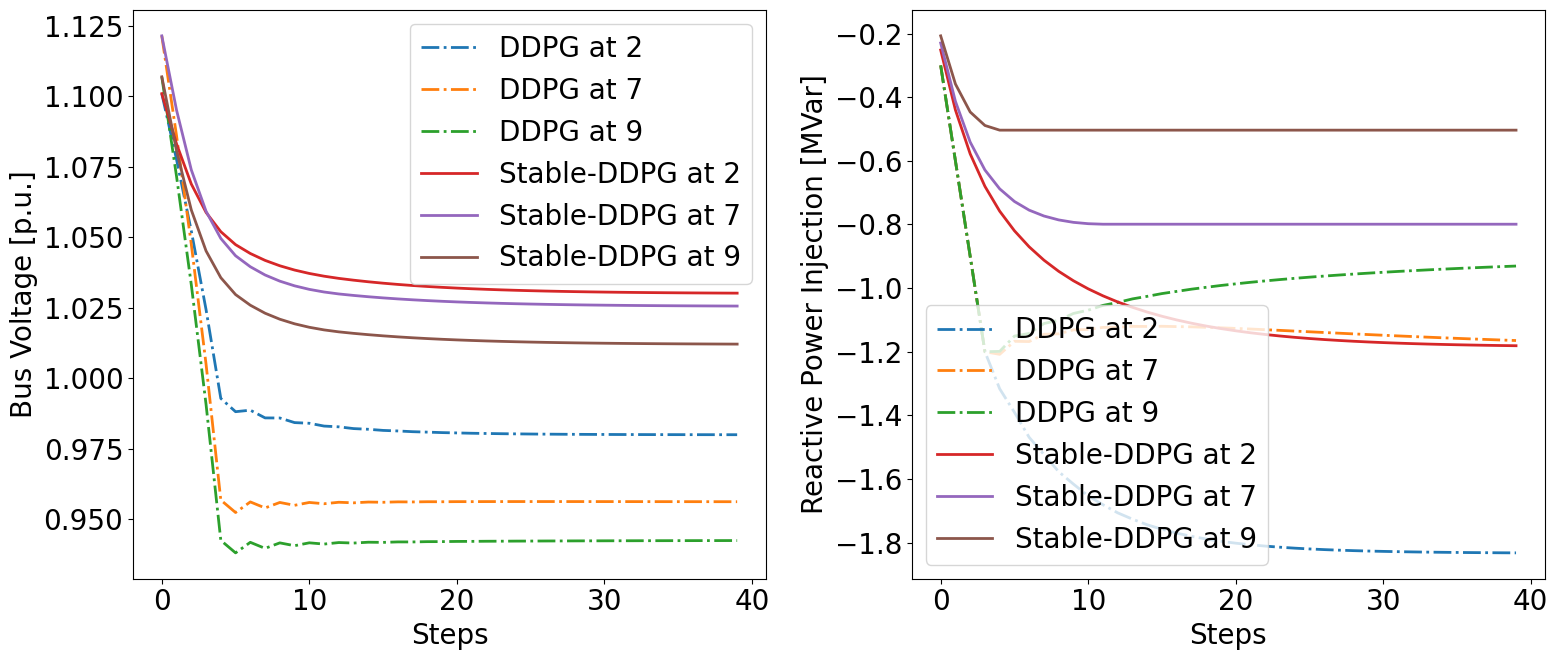

In [ ]:
### Modified test.py: no need to pass argument. Default values are set. args = parser.parse_args([]) # Modified this line
### import collections
'''
This code contains the utilis for test the models, generate the tables we present and the plots.
'''
# from cprofile import label
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from numpy import linalg as LA
import gym
import os
import random
import sys
from gym import spaces
from gym.utils import seeding
import copy
import time

from scipy.io import loadmat
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import argparse

from env_single_phase_13bus import IEEE13bus, create_13bus
from env_single_phase_123bus import IEEE123bus, create_123bus
from safeDDPG import ValueNetwork, SafePolicyNetwork, DDPG, PolicyNetwork, SafePolicy3phase, LinearPolicy
# from IEEE_13_3p import IEEE13bus3p, create_13bus3p
# from IEEE_123_3p import IEEE123bus3p, create_123bus3p


use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")

parser = argparse.ArgumentParser(description='Single Phase Safe DDPG')
parser.add_argument('--env_name', default="13bus",
                    help='name of the environment to run')
parser.add_argument('--algorithm', default='safe-ddpg', help='name of algorithm')
parser.add_argument('--safe_type', default='three_single')
args = parser.parse_args([])
seed = 10
torch.manual_seed(seed)
plt.rcParams['font.size'] = '20'

"""
Create Agent list and replay buffer
"""
max_ac = 0.3
ph_num = 1
slope = 2

if args.env_name == '13bus':
    pp_net = create_13bus()
    injection_bus = np.array([2, 7, 9])
    env = IEEE13bus(pp_net, injection_bus)
    num_agent = 3
if args.env_name == '123bus':
    pp_net = create_123bus()
    injection_bus = np.array([10, 11, 16, 20, 33, 36, 48, 59, 66, 75, 83, 92, 104, 61])-1
    env = IEEE123bus(pp_net, injection_bus)
    num_agent = 14
    max_ac = 0.8
    slope = 5
if args.env_name == '13bus3p':
    # injection_bus = np.array([675,633,680])
    injection_bus = np.array([633,634,671,645,646,692,675,611,652,632,680,684])
    pp_net, injection_bus_dict = create_13bus3p(injection_bus)
    max_ac = 0.4
    env = IEEE13bus3p(pp_net,injection_bus_dict)
    num_agent = len(injection_bus)
    ph_num=3
if args.env_name == '123bus3p':
    injection_bus = np.array([10, 11, 16, 20, 33, 36, 48, 59, 66, 75, 83, 92, 104, 61])
    net, injection_bus_dict = create_123bus3p(injection_bus)
    env = IEEE123bus3p(net, injection_bus_dict)
    num_agent = len(injection_bus)
    max_ac = 0.5
    ph_num=3

if ph_num == 3:
    type_name = 'three-phase'
else:
    type_name = 'single-phase'

obs_dim = env.obs_dim
action_dim = env.action_dim
hidden_dim = 100


ddpg_agent_list = []
safe_ddpg_agent_list = []
linear_agent_list = []

for i in range(num_agent):
    if not ph_num == 3:
        safe_ddpg_value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
        safe_ddpg_policy_net = SafePolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    else:
        if ph_num == 3:
            obs_dim = len(env.injection_bus[env.injection_bus_str[i]])
            action_dim = obs_dim
        safe_ddpg_policy_net = SafePolicy3phase(env, obs_dim, action_dim, hidden_dim, env.injection_bus_str[i]).to(device)
        safe_ddpg_value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)

    ddpg_value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    ddpg_policy_net = PolicyNetwork(env=env, obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)

    ddpg_agent = DDPG(policy_net=ddpg_policy_net, value_net=ddpg_value_net,
                 target_policy_net=ddpg_policy_net, target_value_net=ddpg_value_net)

    linear_value_net  = ValueNetwork(obs_dim=obs_dim, action_dim=action_dim, hidden_dim=hidden_dim).to(device)
    linear_policy_net = LinearPolicy(env,ph_num).to(device)

    linear_agent = DDPG(policy_net=linear_policy_net, value_net=linear_value_net,
                 target_policy_net=linear_policy_net, target_value_net=linear_value_net)

    safe_ddpg_agent = DDPG(policy_net=safe_ddpg_policy_net, value_net=safe_ddpg_value_net,
                 target_policy_net=safe_ddpg_policy_net, target_value_net=safe_ddpg_value_net)

    ddpg_agent_list.append(ddpg_agent)
    safe_ddpg_agent_list.append(safe_ddpg_agent)
    linear_agent_list.append(linear_agent)

for i in range(num_agent):
    ddpg_policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/ddpg/policy_net_checkpoint_a{i}.pth', map_location=device)
    ddpg_agent_list[i].policy_net.load_state_dict(ddpg_policynet_dict)

    linear_policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/linear/policy_net_checkpoint_a{i}.pth', map_location=device)
    linear_agent_list[i].policy_net.load_state_dict(linear_policynet_dict)

    if ph_num == 3:
        safe_ddpg_policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/safe-ddpg/{args.safe_type}/policy_net_checkpoint_a{i}.pth', map_location=device)
        safe_ddpg_agent_list[i].policy_net.load_state_dict(safe_ddpg_policynet_dict)
    else:
        safe_ddpg_policynet_dict = torch.load(f'checkpoints/{type_name}/{args.env_name}/safe-ddpg/policy_net_checkpoint_a{i}.pth', map_location=device)
        safe_ddpg_agent_list[i].policy_net.load_state_dict(safe_ddpg_policynet_dict)


def plot_action():
    """
    This is used to visualize the policy network.
    """
    fig, axs = plt.subplots(1, 1, figsize=(16,12))
    for i in range(num_agent):
        # plot policy
        N = 40
        s_array = np.zeros(N,)

        a_array_baseline = np.zeros(N,)
        safe_ddpg_a_array = np.zeros(N,)

        for j in range(N):
            state = np.array([0.8+0.01*j])
            s_array[j] = state

            safe_ddpg_action = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state]))
            safe_ddpg_action = np.clip(safe_ddpg_action, -max_ac, max_ac)
            safe_ddpg_a_array[j] = -safe_ddpg_action

        axs.plot(s_array, safe_ddpg_a_array, label = f'stable-DDPG at {injection_bus[i]}')
    for i in range(num_agent):
        # plot policy
        N = 40
        s_array = np.zeros(N,)

        a_array_baseline = np.zeros(N,)
        ddpg_a_array = np.zeros(N,)
        safe_ddpg_a_array = np.zeros(N,)

        for j in range(N):
            state = np.array([0.8+0.01*j])
            s_array[j] = state

            action_baseline = (np.maximum(state-1.03, 0)-np.maximum(0.97-state, 0)).reshape((1,))

            ddpg_action = ddpg_agent_list[i].policy_net.get_action(np.asarray([state]))
            ddpg_action = np.clip(ddpg_action, -max_ac, max_ac)
            a_array_baseline[j] = -action_baseline[0]
            ddpg_a_array[j] = -ddpg_action


        axs.plot(s_array, ddpg_a_array, '--', label = f'DDPG at {injection_bus[i]}')
    axs.plot(s_array, 2*a_array_baseline, '-.', label = 'Linear',color='r')
    axs.legend(loc='lower left', prop={"size":20})
    plt.show()

def plot_traj():
    ddpg_plt=[]
    safe_plt = []
    ddpg_a_plt=[]
    safe_a_plt = []

    state = env.reset()
    episode_reward = 0
    last_action = np.zeros((num_agent,1))
    action_list=[]
    state_list =[]
    state_list.append(state)
    for step in range(40):
        action = []
        for i in range(num_agent):
            # sample action according to the current policy and exploration noise
            action_agent = ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))#+np.random.normal(0, 0.05)
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)

        # PI policy
        action = last_action - np.asarray(action)

        # execute action a_t and observe reward r_t and observe next state s_{t+1}
        next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
        if done:
            print("finished")
        action_list.append(action)
        state_list.append(next_state)
        last_action = np.copy(action)
        state = next_state
    fig, axs = plt.subplots(1, 2, figsize=(16,7))
    for i in range(num_agent):
        dps = axs[0].plot(range(len(action_list)), np.array(state_list)[:len(action_list),i], '-.', label = f'DDPG at {injection_bus[i]}', linewidth=2)
        dpa = axs[1].plot(range(len(action_list)), np.array(action_list)[:,i], '-.', label = f'DDPG at {injection_bus[i]}', linewidth=2)
        ddpg_plt.append(dps)
        ddpg_a_plt.append(dpa)

    state = env.reset()
    episode_reward = 0
    last_action = np.zeros((num_agent,1))
    action_list=[]
    state_list =[]
    state_list.append(state)
    for step in range(40):
        action = []
        for i in range(num_agent):
            # sample action according to the current policy and exploration noise
            action_agent = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))#+np.random.normal(0, 0.05)
            # action_agent = (np.maximum(state[i]-1.05, 0)-np.maximum(0.95-state[i], 0)).reshape((1,))*2
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)

        # PI policy
        action = last_action - np.asarray(action)

        # execute action a_t and observe reward r_t and observe next state s_{t+1}
        next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
        if done:
            print("finished")
        action_list.append(action)
        state_list.append(next_state)
        last_action = np.copy(action)
        state = next_state
    safe_name = []
    for i in range(num_agent):
        safes=axs[0].plot(range(len(action_list)), np.array(state_list)[:len(action_list),i], '-', label = f'Stable-DDPG at {injection_bus[i]}', linewidth=2)
        safea=axs[1].plot(range(len(action_list)), np.array(action_list)[:,i], label = f'Stable-DDPG at {injection_bus[i]}', linewidth=2)
        safe_plt.append(safes)
        safe_name.append(f'Stable-DDPG at {injection_bus[i]}')
        safe_a_plt.append(safea)
    # leg1 = plt.legend(safe_a_plt, safe_name, loc='lower left')
    axs[0].legend(loc='upper right', prop={"size":20})
    axs[1].legend(loc='lower left', prop={"size":20})
    axs[0].set_xlabel('Steps')
    axs[1].set_xlabel('Steps')
    axs[0].set_ylabel('Bus Voltage [p.u.]')
    axs[1].set_ylabel('Reactive Power Injection [MVar]')
    plt.tight_layout()
    plt.show()

#test success rate
def test_suc_rate(algm, step_num=60, env_name='13bus'):
    success_num = 0
    final_state_list = []
    final_step_list = []
    control_cost_list = []
    overall_time =0
    for rep in range(500):
        state = env.reset(rep)
        episode_reward = 0
        last_action = np.zeros((num_agent,ph_num))
        action_list=[]
        state_list =[]
        state_list.append(state)
        control_action = []
        for step in range(step_num):
            action = []
            begin_time = time.time()
            for i in range(num_agent):
                if ph_num==3:
                    action_agent = np.zeros(3)
                    phases = env.injection_bus[env.injection_bus_str[i]]
                    id = get_id(phases)
                    if algm == 'linear':
                        action_tmp = linear_agent_list[i].policy_net.get_action(np.asarray([state[i,id]]))
                        action_tmp = action_tmp.reshape(len(id),)
                    elif algm == 'safe-ddpg':
                        action_tmp = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i,id]]))
                        action_tmp = action_tmp.reshape(len(id),)
                    elif algm == 'ddpg':
                        action_tmp = ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i,id]]))
                        action_tmp = action_tmp.reshape(len(id),)
                    # if algm != 'linear':
                    for p in range(len(phases)):
                        action_agent[id[p]]=action_tmp[p]
                    action_agent = np.clip(action_agent, -max_ac, max_ac)
                    action.append(action_agent)
                # sample action according to the current policy and exploration noise
                else:
                    if algm == 'linear':
                        action_agent = linear_agent_list[i].policy_net.get_action(np.asarray([state[i]]))
                    elif algm == 'safe-ddpg':
                        action_agent = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))
                    elif algm == 'ddpg':
                        action_agent = ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))
                    #
                    action_agent = np.clip(action_agent, -max_ac, max_ac)
                    action.append(action_agent)
            end_time=time.time()
            time_elapse = end_time-begin_time
            overall_time += time_elapse
            # PI policy
            action = last_action - np.asarray(action)
            if env_name == '13bus3p':
                control_action.append(np.abs(action)/10) #unit issue. Here action is 0.1 Mvar. Please focus on the ratio for comparison.
            else:
                # Note: there might be unit mismatch for the paper (3 phase), this code can reproduce the exact values reported in the paper.
                control_action.append(np.abs(action))
            # execute action a_t and observe reward r_t and observe next state s_{t+1}
            next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
            if done:
                success_num += 1
                final_step_list.append(step+1)
                control_cost_list.append(np.sum(np.asarray(control_action)))
                break
            action_list.append(last_action-action)
            state_list.append(next_state)
            last_action = np.copy(action)
            state = next_state

        # if not done: # if this is commented out, the metrics here only consider successful cases
        #     final_step_list.append(step_num)
        #     control_cost_list.append(np.sum(np.asarray(control_action)))
        final_state_list.append(next_state)
    print(f'result for {algm} for {env_name}')
    print('Success trials out of 500 trajecotries: ',success_num)
    print(np.mean(final_step_list), np.std(final_step_list))
    print("Elapsed Time: {:.6f} ms".format(overall_time/np.sum(final_step_list)*1000/3))
    print('cost',np.mean(control_cost_list), np.std(control_cost_list))
    return final_state_list

def plot_bar(num_agent):
    print('max')
    xlab = 'Voltage Violation (per test scenario)'
    plt.rcParams['font.size'] = '11'

    plt.figure(figsize=(3.96,2.87),dpi=300)
    plt.gcf().subplots_adjust(bottom=0.17,left=0.15)
    marks=[1.0,0,0,0,0]
    bars=('Stable','5-7%','7-9%','9-10%','>10%')
    y=np.arange(len(bars))
    plt.bar(y+0.2,marks, 0.4,color='b',label='Stable-DDPG')
    state_list = test_suc_rate('ddpg',step_num=100)
    state_list = np.asarray(state_list)
    state_list = np.abs(state_list-1)
    # print(state_list.shape)

    # np.savetxt('state13.txt',state_list)
    # state_list = np.loadtxt('state123h.txt')
    if ph_num == 3:
        state_list_3p = []
        for i in range(num_agent):
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            if len(id)>1:
                # print(np.max(state_list[:,i,id],axis=1).shape)
                state_list_3p.append(np.reshape(np.max(state_list[:,i,id],axis=1), (len(state_list),1)))
            else:
                state_list_3p.append(np.reshape(state_list[:,i,id], (len(state_list),1)))
        state_list_3p = np.concatenate(state_list_3p,axis=1)

    # print(state_list_3p.shape)
    # exit(0)
    if ph_num == 3:
        state_list = state_list_3p
    state_list = np.max(state_list,axis=1)
    # state_list = np.abs(state_list-1)
    marks = [0,0,0,0,0]
    marks[0]=np.sum(state_list<0.05)
    # print(state)
    marks[1]=np.sum(state_list<0.07)-marks[0]
    marks[2]=np.sum(state_list<0.09)-marks[1]-marks[0]
    marks[3]=np.sum(state_list<0.1)-marks[1]-marks[0]-marks[2]
    if ph_num == 3:
        num_agent = state_list_3p.shape[1]
    marks[4]=len(state_list)-marks[1]-marks[0]-marks[2]-marks[3]
    marks = np.array(marks)/len(state_list)
    print(marks)
    plt.bar(y-0.2,marks,0.4,color='r',label='DDPG')

    plt.xticks(y,bars)
    plt.xlabel(xlab)
    plt.ylabel('Frequency')
    plt.legend(loc='upper right')
    plt.show()

def plot_bar_avg(num_agent):
    print('avg')
    xlab = 'Voltage Violation (per bus)'
    plt.rcParams['font.size'] = '11'

    plt.figure(figsize=(3.96,2.87),dpi=300)
    plt.gcf().subplots_adjust(bottom=0.17,left=0.15)
    marks=[1.0,0,0,0,0]
    bars=('Stable','5-7%','7-9%','9-10%','>10%')
    y=np.arange(len(bars))
    plt.bar(y+0.2,marks, 0.4,color='b',label='Stable-DDPG')
    state_list = test_suc_rate('ddpg',step_num=100)
    state_list = np.asarray(state_list)
    if ph_num == 3:
        state_list_3p = []
        for i in range(num_agent):
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            state_list_3p.append(state_list[:,i,id])
        state_list_3p = np.concatenate(state_list_3p,axis=1)

    if ph_num == 3:
        state_list = state_list_3p
    state_list = np.abs(state_list-1)
    marks = [0,0,0,0,0]
    marks[0]=np.sum(state_list<0.05)
    marks[1]=np.sum(state_list<0.07)-marks[0]
    marks[2]=np.sum(state_list<0.09)-marks[1]-marks[0]
    marks[3]=np.sum(state_list<0.1)-marks[1]-marks[0]-marks[2]
    if ph_num == 3:
        num_agent = state_list_3p.shape[1]
    marks[4]=len(state_list)*num_agent-marks[1]-marks[0]-marks[2]-marks[3]
    marks = np.array(marks)/len(state_list)/num_agent
    print(marks)
    plt.bar(y-0.2,marks,0.4,color='r',label='DDPG')

    plt.xticks(y,bars)
    plt.xlabel(xlab)
    plt.ylabel('Frequency')
    plt.legend(loc='upper right')
    plt.show()

def plot_traj_1b_mt():
    color_set = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    fig, axs = plt.subplots(1, 2, figsize=(13,4))
    bus_id = 2#8
    print(f'trajectory of bus {injection_bus[bus_id]+1}')
    for numd in range(5):
        state = env.reset(numd+11)
        episode_reward = 0
        last_action = np.zeros((num_agent,1))
        action_list=[]
        state_list =[]
        state_list.append(state)
        for step in range(50):
            action = []
            for i in range(num_agent):
                # sample action according to the current policy and exploration noise
                action_agent = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))#+np.random.normal(0, 0.05)
                # action_agent = (np.maximum(state[i]-1.05, 0)-np.maximum(0.95-state[i], 0)).reshape((1,))*2
                action_agent = np.clip(action_agent, -max_ac, max_ac)
                action.append(action_agent)

            # PI policy
            action = last_action - np.asarray(action)

            # execute action a_t and observe reward r_t and observe next state s_{t+1}
            next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
            action_list.append(action)
            state_list.append(next_state)
            last_action = np.copy(action)
            state = next_state

        axs[0].plot(range(len(action_list)), np.array(state_list)[:len(action_list),bus_id], '-', label = f'Evolution {numd+1}', linewidth=2,color=color_set[numd])
        axs[1].plot(range(len(action_list)), np.array(action_list)[:,bus_id], label = f'Evolution {numd+1}', linewidth=2,color=color_set[numd])
    lb = axs[0].plot(range(len(action_list)), [0.95]*len(action_list), linestyle='--', dashes=(5, 10), color='g', label=r'$v\underbar$')
    ub = axs[0].plot(range(len(action_list)), [1.05]*len(action_list), linestyle='--', dashes=(5, 10), color='r', label=r'$\bar{v}$');
    # axs[0].legend()
    box = axs[0].get_position()
    axs[0].set_position([box.x0-0.05*box.width, box.y0+0.1*box.height,
                    box.width* 0.87, box.height])
    box = axs[1].get_position()
    axs[1].set_position([box.x0-0.12*box.width, box.y0+0.1*box.height,
                    box.width* 0.87, box.height])
    axs[0].legend(loc='right', bbox_to_anchor=(2.90, 0.4),
        fancybox=True, shadow=True, ncol=1, prop={"size":13})
    axs[0].set_xlabel('Iteretion Steps')
    axs[1].set_xlabel('Iteretion Steps')
    axs[0].set_xticks(np.arange(0, 50, step=20))
    axs[1].set_xticks(np.arange(0, 50, step=20))
    axs[0].set_yticks(np.arange(0.85, 1.2, step=0.05))
    axs[1].set_yticks(np.arange(-5, 3, step=2.5))
    axs[0].set_ylabel('Bus Voltage [p.u.]')
    axs[1].set_ylabel('q Injection [MVar]')
    plt.show()

#11, 36, 75
def plot_traj_123(seed): #only for 123 bus
    color_set = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    ddpg_plt=[]
    safe_plt = []
    ddpg_a_plt=[]
    safe_a_plt = []

    state = env.reset(seed)
    episode_reward = 0
    last_action = np.zeros((num_agent,1))
    action_list=[]
    state_list =[]
    state_list.append(state)
    for step in range(100):
        action = []
        for i in range(num_agent):
            # sample action according to the current policy and exploration noise
            action_agent = ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))#+np.random.normal(0, 0.05)
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)

        # PI policy
        action = last_action - np.asarray(action)

        # execute action a_t and observe reward r_t and observe next state s_{t+1}
        next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
        if done:
            print("finished")
        action_list.append(action)
        state_list.append(next_state)
        last_action = np.copy(action)
        state = next_state
    fig, axs = plt.subplots(1, 2, figsize=(13,4))
    # lb = axs[0].plot(range(len(action_list)), [0.95]*len(action_list), linestyle='--', dashes=(5, 10), color='g', label='lower bound')
    # ub = axs[0].plot(range(len(action_list)), [1.05]*len(action_list), linestyle='--', dashes=(5, 10), color='r', label='upper bound')
    for idx,i in enumerate([2,5,8]):    #[2,5,10]
        dps = axs[0].plot(range(len(action_list)), np.array(state_list)[:len(action_list),i], '-.', label = f'DDPG at {injection_bus[i]+1}', linewidth=2,color=color_set[idx])
        dpa = axs[1].plot(range(len(action_list)), np.array(action_list)[:,i], '-.', label = f'DDPG at {injection_bus[i]+1}', linewidth=2,color=color_set[idx])
        ddpg_plt.append(dps)
        ddpg_a_plt.append(dpa)

    state = env.reset(seed)
    episode_reward = 0
    last_action = np.zeros((num_agent,1))
    action_list=[]
    state_list =[]
    state_list.append(state)
    for step in range(100):
        action = []
        for i in range(num_agent):
            # sample action according to the current policy and exploration noise
            action_agent = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state[i]]))#+np.random.normal(0, 0.05)
            # action_agent = (np.maximum(state[i]-1.05, 0)-np.maximum(0.95-state[i], 0)).reshape((1,))*2
            action_agent = np.clip(action_agent, -max_ac, max_ac)
            action.append(action_agent)

        # PI policy
        action = last_action - np.asarray(action)

        # execute action a_t and observe reward r_t and observe next state s_{t+1}
        next_state, reward, reward_sep, done = env.step_Preward(action, (last_action-action))
        if done:
            print("finished")
        action_list.append(action)
        state_list.append(next_state)
        last_action = np.copy(action)
        state = next_state
    safe_name = []
    for idx,i in enumerate([2,5,8]):
        safes=axs[0].plot(range(len(action_list)), np.array(state_list)[:len(action_list),i], '-', label = f'Stable-DDPG at {injection_bus[i]+1}', linewidth=2,color=color_set[idx])
        safea=axs[1].plot(range(len(action_list)), np.array(action_list)[:,i], label = f'Stable-DDPG at {injection_bus[i]+1}', linewidth=2,color=color_set[idx])
        safe_plt.append(safes)
        safe_name.append(f'stable-DDPG at {injection_bus[i]}')
        safe_a_plt.append(safea)
    # leg1 = plt.legend(safe_a_plt, safe_name, loc='lower left')
    # axs[0].legend(loc='lower left', prop={"size":20})
    # axs[1].legend(loc='lower left', prop={"size":20})
    box = axs[0].get_position()
    axs[0].set_position([box.x0-0.05*box.width, box.y0+0.1*box.height,
                    box.width* 0.87, box.height])
    box = axs[1].get_position()
    axs[1].set_position([box.x0-0.12*box.width, box.y0+0.1*box.height,
                    box.width* 0.87, box.height])
    axs[0].legend(loc='right', bbox_to_anchor=(2.92, 0.4),
        fancybox=True, shadow=True, ncol=1, prop={"size":13})
    axs[0].set_xlabel('Iteretion Steps')
    axs[1].set_xlabel('Iteretion Steps')
    axs[0].set_ylabel('Bus Voltage [p.u.]')
    axs[1].set_ylabel('q Injection [MVar]')
    plt.show()

def plot_action_selcted(selected=[1,5,9]):
    color_set = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    # if ph_num ==3:
    #     injection_bus = [3,6,5,2,4,9,12,10,11,1,8,7]
    fig, axs = plt.subplots(1, 3, figsize=(12,4))
    plt.gcf().subplots_adjust(bottom=0.18)
    for indx,i in enumerate(selected):
        # plot policy
        N = 40
        s_array = np.zeros(N,)

        a_array_baseline = np.zeros(N,)
        safe_ddpg_a_array = np.zeros((N,ph_num))

        for j in range(N):
            if ph_num == 1:
                state = np.array([0.8+0.01*j])
                s_array[j] = state
            else:
                state = np.resize(np.array([0.8+0.01*j]),(3))
                s_array[j] = state[0]

            if ph_num == 3:
                safe_ddpg_action = np.zeros(3)
                phases = env.injection_bus[env.injection_bus_str[i]]
                id = get_id(phases)
                action_tmp = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state[id]]))
                action_tmp = action_tmp.reshape(len(id),)
                for p in range(len(phases)):
                    safe_ddpg_action[id[p]]=action_tmp[p]
            else:
                safe_ddpg_action = safe_ddpg_agent_list[i].policy_net.get_action(np.asarray([state]))
            safe_ddpg_action = np.clip(safe_ddpg_action, -max_ac, max_ac)
            safe_ddpg_a_array[j] = -safe_ddpg_action
        if ph_num == 1:
            axs[indx].plot(s_array, safe_ddpg_a_array, label = f'Stable-DDPG', linewidth=2)
        else:
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            for cnt, ph_id in enumerate(id):
                clr = color_set[ph_id]
                axs[indx].plot(s_array, safe_ddpg_a_array[:,ph_id], label = f'Stable-DDPG-{phases[cnt]}', linewidth=2, color=clr)
    for indx,i in enumerate(selected):
        # plot policy
        N = 40
        s_array = np.zeros(N,)

        a_array_baseline = np.zeros(N,)
        linear_a_array = np.zeros((N,ph_num))

        for j in range(N):
            if ph_num == 1:
                state = np.array([0.8+0.01*j])
                s_array[j] = state
            else:
                state = np.resize(np.array([0.8+0.01*j]),(3))
                s_array[j] = state[0]

            if ph_num == 3:
                safe_ddpg_action = np.zeros(3)
                phases = env.injection_bus[env.injection_bus_str[i]]
                id = get_id(phases)
                action_tmp = linear_agent_list[i].policy_net.get_action(np.asarray([state[id]]))
                action_tmp = action_tmp.reshape(len(id),)
                for p in range(len(phases)):
                    safe_ddpg_action[id[p]]=action_tmp[p]
            else:
                safe_ddpg_action = linear_agent_list[i].policy_net.get_action(np.asarray([state]))
            safe_ddpg_action = np.clip(safe_ddpg_action, -max_ac, max_ac)
            linear_a_array[j] = -safe_ddpg_action
        if ph_num == 1:
            axs[indx].plot(s_array, linear_a_array, ':', label = f'Linear', linewidth=2, color='r')
        else:
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            axs[indx].plot(s_array, linear_a_array[:,id[0]], ':', label = f'Linear', linewidth=2, color='r')

    for indx,i in enumerate(selected):
        # plot policy
        N = 40
        s_array = np.zeros(N,)

        a_array_baseline = np.zeros(N,)
        ddpg_a_array = np.zeros((N,ph_num))
        # safe_ddpg_a_array = np.zeros(N,)

        for j in range(N):
            if ph_num == 1:
                state = np.array([0.8+0.01*j])
                s_array[j] = state
            else:
                state = np.resize(np.array([0.8+0.01*j]),(3))
                s_array[j] = state[0]

            # action_baseline = (np.maximum(state[0]-1.03, 0)-np.maximum(0.97-state[0], 0)).reshape((1,))*slope

            if ph_num == 3:
                ddpg_action = np.zeros(3)
                phases = env.injection_bus[env.injection_bus_str[i]]
                id = get_id(phases)
                action_tmp = ddpg_agent_list[i].policy_net.get_action(np.asarray([state[id]]))
                action_tmp = action_tmp.reshape(len(id),)
                for p in range(len(phases)):
                    ddpg_action[id[p]]=action_tmp[p]
            else:
                ddpg_action = ddpg_agent_list[i].policy_net.get_action(np.asarray([state]))
            ddpg_action = np.clip(ddpg_action, -max_ac, max_ac)
            # action_baseline = np.clip(action_baseline, -max_ac, max_ac)
            # a_array_baseline[j] = -action_baseline[0]
            ddpg_a_array[j] = -ddpg_action
        if indx != 0:
            axs[indx].get_yaxis().set_visible(False)
        axs[indx].set_title(f'Bus {injection_bus[i]+1}', size=20)
        if ph_num==1:
            axs[indx].plot(s_array, ddpg_a_array, '--', label = f'DDPG', linewidth=2)
        else:
            phases = env.injection_bus[env.injection_bus_str[i]]
            id = get_id(phases)
            for cnt, ph_id in enumerate(id):
                clr = color_set[ph_id+3]
                axs[indx].plot(s_array, ddpg_a_array[:,ph_id], '--', label = f'DDPG-{phases[cnt]}', linewidth=2, color=clr)
        # axs[indx].plot(s_array, a_array_baseline, ':', label = 'Linear',color='r', linewidth=2)

        # axs[indx].legend(loc='lower left', prop={"size":13})
        axs[indx].set_xlabel('voltage magnitude [p.u.]', size=18)
        axs[indx].set_ylabel(f'q change [MVar]', size=18)

    box = axs[0].get_position()
    axs[0].set_position([box.x0-0.15*box.width, box.y0,
                    box.width* 0.9, box.height])
    box = axs[1].get_position()
    axs[1].set_position([box.x0-0.19*box.width, box.y0,
                    box.width* 0.9, box.height])
    box = axs[2].get_position()
    axs[2].set_position([box.x0-0.22*box.width, box.y0,
                    box.width* 0.9, box.height])
    axs[0].legend(loc='right', bbox_to_anchor=(4.45, 0.4),
        fancybox=True, shadow=True, ncol=1, prop={"size":13})
    plt.show()

def get_id(phases):
    if phases == 'abc':
        id = [0,1,2]
    elif phases == 'ab':
        id = [0,1]
    elif phases == 'ac':
        id = [0,2]
    elif phases == 'bc':
        id = [1,2]
    elif phases == 'a':
        id = [0]
    elif phases == 'b':
        id = [1]
    elif phases == 'c':
        id = [2]
    else:
        print("error!")
        exit(0)
    return id


if __name__ == "__main__":
    # plot_traj_1b_mt()
    # print("test")
    test_suc_rate('safe-ddpg',step_num=100, env_name=args.env_name) #safe-ddpg
    test_suc_rate('linear',step_num=100, env_name=args.env_name)
    test_suc_rate('ddpg',step_num=100, env_name=args.env_name) #now only successful cases are considered.
    # plot_bar_avg(len(injection_bus))
    # plot_bar(len(injection_bus))
    # test_suc_rate('linear')
    # plot_action_selcted()
    # plot_bar(len(injection_bus))
    # plot_traj_123(19)
    # plot_action_selcted([1,4,9]) #13b3p
    # plot_action_selcted([2,4,10]) #13b3p
    # plot_action_selcted([2,5,8]) #123b
    # plot_action_selcted([0,1,2])
    plot_traj()